# Introducing Scikit-Learn Library

[Scikit-Learn](http://scikit-learn.org) (http://scikit-learn.org), library provides solid implementations of a range of machine learning algorithms in Python to build predictive models.

Scikit-Learn has a great documentation with plenty of examples at (https://scikit-learn.org/stable/auto_examples/index.html). Once you understand the basic use and syntax of Scikit-Learn for one type of model, switching to a new model or algorithm becomes very straightforward.

We are going to learn:
- how *data representation* is done in Scikit-Learn.
- how *Estimator* API (Application Protocol Interface) works.
- how to use Scikit-Learn tools with different examples.


## Data Representation in Scikit-Learn

Machine learning is about creating models from data: for that reason, we'll start by discussing how data can be represented in order to be understood by the computer.
The best way to think about data within Scikit-Learn is in terms of tables of data.

### Data as table

A basic table is a two-dimensional grid of data, in which the rows represent individual elements of the dataset, and the columns represent quantities related to each of these elements.
For example, consider the [Iris dataset](https://en.wikipedia.org/wiki/Iris_flower_data_set) (https://en.wikipedia.org/wiki/Iris_flower_data_set), famously analyzed by Ronald Fisher in 1936.
We can download this dataset in the form of a Pandas ``DataFrame`` using the [seaborn](http://seaborn.pydata.org/) library:

In [ ]:
import seaborn as sns
iris = sns.load_dataset('iris')
iris

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [ ]:
type(iris)

pandas.core.frame.DataFrame

Here each row of the data refers to a single observed flower, and the number of rows is the total number of flowers in the dataset.
In general, we will refer to the rows of the matrix as *samples*, and the number of rows as ``n_samples``.

- *samples*
- ``n_samples``

Likewise, each column of the data refers to a particular quantitative piece of information that describes each sample.
In general, we will refer to the columns of the matrix as *features*, and the number of columns as ``n_features``.

- *features*
- ``n_features``


#### Features matrix

This table layout makes clear that the information can be thought of as a two-dimensional numerical array or matrix, which we will call the *features matrix*.

- *features matrix* ``X`` ``[n_samples, n_features]``

By convention, this features matrix is often stored in a variable named ``X``.
The features matrix is assumed to be two-dimensional, with shape ``[n_samples, n_features]``, and is most often contained in a NumPy array or a Pandas ``DataFrame``, though some Scikit-Learn models also accept SciPy sparse matrices.

The samples (i.e., rows) always refer to the individual objects described by the dataset.
For example, the sample might be a flower, a person, a document, an image, a sound file, a video, an astronomical object, or anything else you can describe with a set of quantitative measurements.

The features (i.e., columns) always refer to the distinct observations that describe each sample in a quantitative manner.
Features are generally real-valued, but may be Boolean or discrete-valued in some cases.

#### Target array

In addition to the feature matrix ``X``, we also generally work with a *label* or *target* array, which by convention we will usually call ``y``.
The target array is usually one dimensional, with length ``n_samples``, and is generally contained in a NumPy array or Pandas ``Series``.
The target array may have continuous numerical values, or discrete classes/labels.
While some Scikit-Learn estimators do handle multiple target values in the form of a two-dimensional, ``[n_samples, n_targets]`` target array, we will primarily be working with the common case of a one-dimensional target array.

Often one point of confusion is how the target array differs from the other features columns. The distinguishing feature of the target array is that it is usually the quantity we want to *predict from the data*: in statistical terms, it is the dependent variable.
For example, in the preceding data we may wish to construct a model that can predict the species of flower based on the other measurements; in this case, the ``species`` column would be considered the target array.

With this target array ``species`` in mind, we can use Seaborn package to conveniently visualize the data, creating pairplots distinguished by colors for different species as follows:

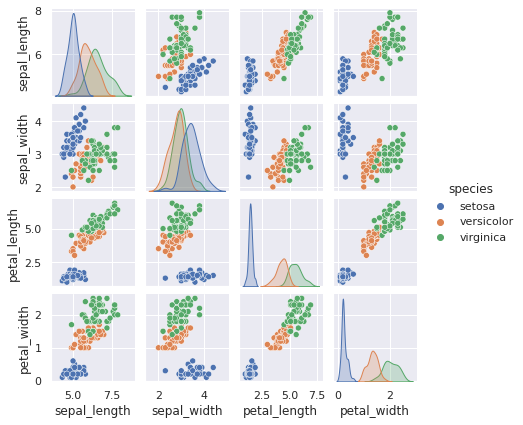

In [ ]:
%matplotlib inline
import seaborn as sns
sns.set()
sns.pairplot(iris, hue='species', height=1.5);

For use in Scikit-Learn, we will extract the features matrix and target array from the ``DataFrame``, using some of the Pandas ``DataFrame`` operations that we have covered before.

In [ ]:
iris

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [ ]:
# dropping species column to obtain features matrix
X_iris = iris.drop('species', axis=1)
X_iris.shape

(150, 4)

In [ ]:
# extracting species column to obtain target array
y_iris = iris['species']
y_iris.shape

(150,)

To summarize, the expected layout of features and target values is visualized in the following diagram:

![](https://github.com/jakevdp/PythonDataScienceHandbook/blob/master/notebooks/figures/05.02-samples-features.png?raw=1)
figure source https://github.com/jakevdp/PythonDataScienceHandbook/blob/master/notebooks/figures/05.02-samples-features.png?raw=1

With this data properly formatted, we can move on to consider the *estimator* API of Scikit-Learn:
- **Important Step**: format the data properly in the form of Feeatures Matrix and Target Vector


## Scikit-Learn's Estimator API

The Scikit-Learn API is designed with the following guiding principles in mind, as outlined in the [Scikit-Learn API paper](http://arxiv.org/abs/1309.0238):

- **Consistency**: All objects share a common interface drawn from a limited set of methods, with consistent documentation.

- **Inspection**: All specified parameter values are exposed as public attributes.

- **Limited object hierarchy**: Only algorithms are represented by Python classes; datasets are represented
  in standard formats (NumPy arrays, Pandas ``DataFrame``s, SciPy sparse matrices) and parameter
  names use standard Python strings.

- **Composition**: Many machine learning tasks can be expressed as sequences of more fundamental algorithms,
  and Scikit-Learn makes use of this wherever possible.

- **Sensible defaults**: When models require user-specified parameters, the library defines an appropriate default value.

In practice, these principles make Scikit-Learn very easy to use, once the basic principles are understood.
Every machine learning algorithm in Scikit-Learn is implemented via the Estimator API, which provides a consistent interface for a wide range of machine learning applications.

### Basics of the Estimator API

The steps in using the Scikit-Learn estimator API are as follows:


1. Choose a class of model by importing the appropriate estimator class from Scikit-Learn.
2. Choose model hyperparameters by instantiating this class with desired values.
3. Arrange data into a features matrix and target vector following the discussion above.
4. Fit the model to your data by calling the ``fit()`` method of the model instance.
5. Apply the Model to new data:
   - For supervised learning, often we predict labels for unknown data using the ``predict()`` method.
   - For unsupervised learning, we often transform or infer properties of the data using the ``transform()`` or ``predict()`` method.

Let us go through several simple examples of using Scikit-Learn library.

### Supervised learning example: Simple linear regression model

Let's consider a simple linear regression using a simple data -- fitting a linear line to data.

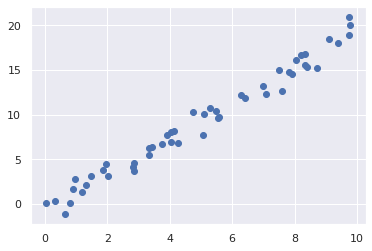

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# produce some random features matrix data and target vector data for our regression model
rng = np.random.RandomState(999) # set a common random seed to make sure that we all have the same results.

x = 10 * rng.rand(50)
y = 2 * x - 1 + rng.randn(50)


plt.scatter(x, y);
# clearly x and y are highly correlated with each other by design

With this data in place, we can use the recipe outlined earlier. Let's walk through the process: 

#### 1. Choose model class
#### 2. Instantiate model
#### 3. Arrange data
#### 4. Fit model to data
#### 5. Predict on new data

#### **1**. Choose a class of model

In Scikit-Learn, every class of model is represented by a Python class.
For example, if we would like to compute a simple linear regression model, we can import the linear regression class as follows:

In [ ]:
from sklearn.linear_model import LinearRegression


Note that other more general linear regression models exist as well; you can read more about them in the [``sklearn.linear_model`` module documentation](http://Scikit-Learn.org/stable/modules/linear_model.html).

#### **2**. Choose model hyperparameters

It is important to point that *a class of model is not the same as an instance of a model*. Thus, after importing a class of model, we have to instantiate it. We also have to choose hyperparameters through passing values at model instantiation. Hyper-parameters are parameters that are not directly learnt within estimators. In scikit-learn they are passed as arguments to the constructor of the estimator classes. Hyperparameters (or parameters) must be set before the model is fit to data. For example, the answers to the following questions would help us in assinging values for our hyperparameters during instantiation of the model class.

- Would we like to fit the intercept?
- Would we like the model to be normalized?
- What degree of regularization would we like to use in our model?
- What degree of flexibility would we like to use in our model?


For our linear regression example, we can instantiate the ``LinearRegression`` class and specify that we would like to fit the intercept using the ``fit_intercept`` hyperparameter:

In [ ]:
model = LinearRegression()
model

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None, normalize=False)

Keep in mind that when the model is instantiated, the only action is the storing of these hyperparameter values. 

In particular, we have not yet applied the model to any data: the Scikit-Learn API makes very clear the distinction between *choice of model* and *application of model to data*.

#### **3**. Arrange data into a features matrix and target vector

In Scikit-Learn, data representation requires a two-dimensional features matrix and a one-dimensional target array. Here our target variable ``y`` is already in the correct form (a length-``n_samples`` array), but we need to massage the data ``x`` to make it a matrix of size ``[n_samples, n_features]``.

In this case, this amounts to a simple reshaping of the one-dimensional array:


In [ ]:
x

array([8.0342804 , 5.27522296, 1.19111465, 6.39681444, 0.90925263,
       3.32225681, 4.27380947, 5.54385812, 6.28126522, 6.97392944,
       7.89949689, 1.31890353, 3.42770452, 2.01559611, 7.0732423 ,
       0.33399264, 9.09250044, 4.05160665, 7.6043547 , 4.73758376,
       2.86718918, 7.51292489, 0.97089943, 4.12357788, 2.81638963,
       3.90277781, 8.7110921 , 0.81245117, 5.57931165, 5.47534279,
       3.3220307 , 9.73268814, 2.86276098, 5.08257499, 1.47950736,
       1.96433985, 8.40820011, 0.03753203, 7.8262101 , 8.33477717,
       9.37907338, 9.72601663, 8.32823042, 0.65817606, 4.0379256 ,
       3.74793486, 5.07501347, 9.7787696 , 8.18990209, 1.87541244])

In [ ]:
x.shape

(50,)

WE NEED TO CONVERT THIS ARRAY INTO A MATRIX!

In [ ]:
X = x[:, np.newaxis]
X.shape

# Alternatively, you can use the following for reshaping of the one-dimensional array
# x.reshape(-1,1)

(50, 1)

#### 4. Fit the model to your data

Now it is time to apply our model to data.
This can be done with the ``fit()`` method of the model:

In [ ]:
model.fit(X, y)



LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None, normalize=False)

This ``fit()`` command causes a number of model-dependent internal computations to take place, and the results of these computations are stored in model-specific attributes that the user can explore.
In Scikit-Learn, by convention all model parameters that were learned during the ``fit()`` process have trailing underscores; for example in this linear model, we have the following:

In [ ]:
model.coef_

array([2.01099168])

In [ ]:
model.intercept_

-0.699082144400176

These two parameters represent the slope and intercept of the simple linear fit to the data.
Comparing to the data definition, we see that they are very close to the input slope of 2 and intercept of -1.

In general, Scikit-Learn does not provide tools to draw conclusions from internal model parameters themselves: interpreting model parameters is much more a *statistical modeling* question than a *machine learning* question.
Machine learning rather focuses on what the model *predicts*.
If you would like to dive into the meaning of fit parameters within the model, other tools are available, including the [Statsmodels Python package](http://statsmodels.sourceforge.net/).

#### **5**. Predict labels for unknown data

Once the model is trained, the main task of supervised machine learning is to evaluate it based on what it says about new data that was not part of the training set.
In Scikit-Learn, this can be done using the ``predict()`` method.
For the sake of this example, our "new data" will be a grid of *x* values, and we will ask what *y* values the model predicts:

In [ ]:
xfit = np.linspace(-1, 11)

In [ ]:
xfit

array([-1.        , -0.75510204, -0.51020408, -0.26530612, -0.02040816,
        0.2244898 ,  0.46938776,  0.71428571,  0.95918367,  1.20408163,
        1.44897959,  1.69387755,  1.93877551,  2.18367347,  2.42857143,
        2.67346939,  2.91836735,  3.16326531,  3.40816327,  3.65306122,
        3.89795918,  4.14285714,  4.3877551 ,  4.63265306,  4.87755102,
        5.12244898,  5.36734694,  5.6122449 ,  5.85714286,  6.10204082,
        6.34693878,  6.59183673,  6.83673469,  7.08163265,  7.32653061,
        7.57142857,  7.81632653,  8.06122449,  8.30612245,  8.55102041,
        8.79591837,  9.04081633,  9.28571429,  9.53061224,  9.7755102 ,
       10.02040816, 10.26530612, 10.51020408, 10.75510204, 11.        ])

In [ ]:
xfit.shape

(50,)

As before, we need to coerce these *x* values into a ``[n_samples, n_features]`` features matrix, after which we can feed it to the model:

In [ ]:
Xfit = xfit[:, np.newaxis]
yfit = model.predict(Xfit)

In [ ]:
yfit

array([-2.71007383, -2.21758607, -1.72509831, -1.23261055, -0.74012279,
       -0.24763503,  0.24485273,  0.73734049,  1.22982825,  1.722316  ,
        2.21480376,  2.70729152,  3.19977928,  3.69226704,  4.1847548 ,
        4.67724256,  5.16973032,  5.66221808,  6.15470584,  6.6471936 ,
        7.13968136,  7.63216912,  8.12465687,  8.61714463,  9.10963239,
        9.60212015, 10.09460791, 10.58709567, 11.07958343, 11.57207119,
       12.06455895, 12.55704671, 13.04953447, 13.54202223, 14.03450998,
       14.52699774, 15.0194855 , 15.51197326, 16.00446102, 16.49694878,
       16.98943654, 17.4819243 , 17.97441206, 18.46689982, 18.95938758,
       19.45187534, 19.94436309, 20.43685085, 20.92933861, 21.42182637])

Finally, let's visualize the results by plotting first the raw data, and then this model fit:

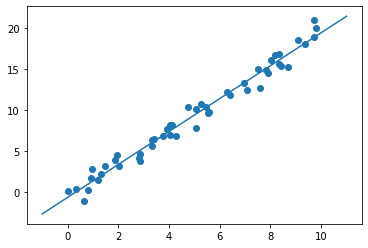

In [ ]:
plt.scatter(x, y)
plt.plot(xfit, yfit);

Typically the efficacy of the model is evaluated by comparing its results to some known baseline, as we will see in the next example

### Supervised learning example: Iris classification

Let us use the Iris dataset to illustrate a classification problem. 

**Question:** given a model trained on a portion of the Iris data, how well can we predict the remaining labels?

For this classification problem, let us use an extremely simple generative model known as Gaussian naive Bayes, which proceeds by assuming each class is drawn from an axis-aligned Gaussian distribution. 

Because it is so fast and has no hyperparameters to choose, Gaussian naive Bayes is often a good model to use as a baseline classification, before exploring whether improvements can be found through more sophisticated models.


We would like to evaluate the model on data it has not seen before. Therefore, we can split the data into a *training set* and a *testing set* by using the ``train_test_split`` utility function:

In [ ]:
iris.shape

(150, 5)

In [ ]:
X_iris.shape

(150, 4)

In [ ]:
from sklearn.model_selection import train_test_split
Xtrain, Xtest, ytrain, ytest = train_test_split(X_iris, y_iris, test_size=0.25, random_state=1)


In [ ]:
Xtrain.shape

(112, 4)

In [ ]:
Xtrain

,sepal_length,sepal_width,petal_length,petal_width
54,6.5,2.8,4.6,1.5
108,6.7,2.5,5.8,1.8
112,6.8,3.0,5.5,2.1
17,5.1,3.5,1.4,0.3
119,6.0,2.2,5.0,1.5
...,...,...,...,...
133,6.3,2.8,5.1,1.5
137,6.4,3.1,5.5,1.8
72,6.3,2.5,4.9,1.5
140,6.7,3.1,5.6,2.4


With the data arranged, we can follow our steps in Scikit-Learn to predict the class labels:

In [ ]:
from sklearn.naive_bayes import GaussianNB # 1. choose model class

model = GaussianNB()                       # 2. instantiate model
model.fit(Xtrain, ytrain)                  # 3. fit model to data (i.e., machine learning happening)
y_model = model.predict(Xtest)             # 4. predict on new data



WE can compare y_model to y_test to determine the percentage of correct predictions!

In [ ]:
y_model

array(['setosa', 'versicolor', 'versicolor', 'setosa', 'virginica',
       'versicolor', 'virginica', 'setosa', 'setosa', 'virginica',
       'versicolor', 'setosa', 'virginica', 'versicolor', 'versicolor',
       'setosa', 'versicolor', 'versicolor', 'setosa', 'setosa',
       'versicolor', 'versicolor', 'virginica', 'setosa', 'virginica',
       'versicolor', 'setosa', 'setosa', 'versicolor', 'virginica',
       'versicolor', 'virginica', 'versicolor', 'virginica', 'virginica',
       'setosa', 'versicolor', 'setosa'], dtype='<U10')

In [ ]:
ytest #correct labels for your test flowers

14         setosa
98     versicolor
75     versicolor
16         setosa
131     virginica
56     versicolor
141     virginica
44         setosa
29         setosa
120     virginica
94     versicolor
5          setosa
102     virginica
51     versicolor
78     versicolor
42         setosa
92     versicolor
66     versicolor
31         setosa
35         setosa
90     versicolor
84     versicolor
77     versicolor
40         setosa
125     virginica
99     versicolor
33         setosa
19         setosa
73     versicolor
146     virginica
91     versicolor
135     virginica
69     versicolor
128     virginica
114     virginica
48         setosa
53     versicolor
28         setosa
Name: species, dtype: object

Finally, we can use the ``accuracy_score`` utility to see the fraction of predicted labels that match their true value:

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(ytest, y_model)

0.9736842105263158

With an accuracy topping 97%, we see that even this very naive classification algorithm is effective for this particular dataset!

## Application: Exploring Hand-written Digits

To demonstrate these principles on a more interesting problem, let's consider one piece of the optical character recognition problem: the identification of hand-written digits.
In the wild, this problem involves both locating and identifying characters in an image. 

### Loading and visualizing the digits data

Let us use Scikit-Learn's data access interface and take a look at this data:

In [ ]:
from sklearn.datasets import load_digits
digits = load_digits()
digits.images.shape

(1797, 8, 8)

The images data is a three-dimensional array: 1,797 samples each consisting of an 8 × 8 grid of pixels.
Let's visualize the first hundred of these:

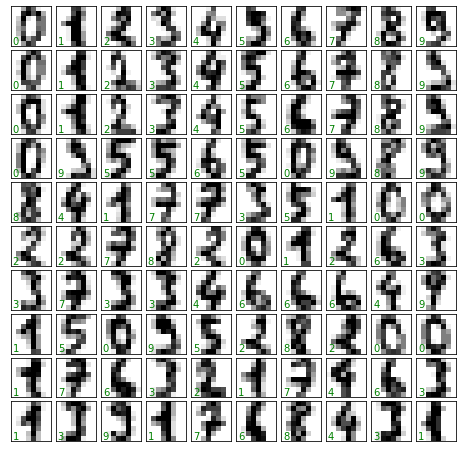

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(10, 10, figsize=(8, 8),
                         subplot_kw={'xticks':[], 'yticks':[]},
                         gridspec_kw=dict(hspace=0.1, wspace=0.1))

for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap='binary', interpolation='nearest')
    ax.text(0.05, 0.05, str(digits.target[i]),
            transform=ax.transAxes, color='green')

In order to work with this data within Scikit-Learn, we need a two-dimensional, ``[n_samples, n_features]`` representation.
We can accomplish this by treating each pixel in the image as a feature: that is, by flattening out the pixel arrays so that we have a length-64 array of pixel values representing each digit.
Additionally, we need the target array, which gives the previously determined label for each digit.
These two quantities are built into the digits dataset under the ``data`` and ``target`` attributes, respectively:

In [ ]:
type(digits)

sklearn.utils.Bunch

In [ ]:
X = digits.data
X.shape

(1797, 64)

In [ ]:
y = digits.target
y.shape

(1797,)

We see here that there are 1,797 samples and 64 features.

### Classification on digits

Let's apply a classification algorithm to the digits.
As with the Iris data previously, we will split the data into a training and testing set, and fit a Gaussian naive Bayes model:

In [ ]:
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, random_state=0)

In [ ]:
from sklearn.naive_bayes import GaussianNB #import the class
model = GaussianNB() #instantiate the class
model.fit(Xtrain, ytrain) #learn from the train data 
y_model = model.predict(Xtest) #make predictions on the test data


Now that we have predicted our model, we can gauge its accuracy by comparing the true values of the test set to the predictions:

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(ytest, y_model)

0.8333333333333334

With even this extremely simple model, we find about 83% accuracy for classification of the digits! However, this percentage of accuracy doesn't tell us *where* we've done wrong estimations. We can get a better picture by using the *confusion matrix*. We can compute the confusion matrix with Scikit-Learn and plot it with Seaborn to visually analyze it as follows:

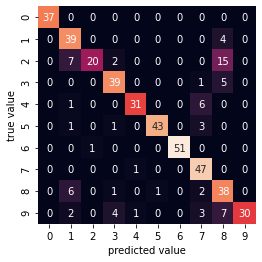

In [ ]:
from sklearn.metrics import confusion_matrix

mat = confusion_matrix(ytest, y_model)

sns.heatmap(mat, square=True, annot=True, cbar=False)
plt.xlabel('predicted value')
plt.ylabel('true value');

This confusion matrix shows us that a large number of twos  are misclassified as either ones or eights.


We also note that we can use more advanced models such as support vector machines or random forests instead of Gaussian naive Bayes model to improve the prediction accuracy from 83% to a higher value. 